# LOGIVISION — Train YOLOv8 on Google Colab (T4)

**Purpose.** Fine-tune YOLOv8n on the **LOCO** real-warehouse dataset
using a free Colab T4 GPU. 50 epochs at 640 px takes **~25 minutes on
T4**, vs hours on an M3 CPU.

## Before you run

1. *Runtime → Change runtime type → T4 GPU* (confirm top-right).
2. That's it — **no credentials needed**. LOCO is public-domain (CC0),
   so the download cell needs no Kaggle/login setup.

## What this notebook does

Trains on **LOCO** (Logistics Objects in Context) — real photos from five
operating warehouse environments. Classes: `small_load_carrier, forklift,
pallet, stillage, pallet_truck`.

| Cell | Step | Time on T4 |
|---|---|---|
| 1 | Detect Colab; clone repo (depth=1) | 5 s |
| 2 | Install ultralytics, pyyaml, mlflow | 30 s |
| 3 | (no-op — LOCO needs no credentials) | <1 s |
| 4 | Download LOCO (~769 MB, CC0) | 1-3 min |
| 5 | Convert COCO → YOLO, scene-separated split (`scripts/prepare_loco.py`) | 20 s |
| 6 | Train YOLOv8n: 50 epochs, imgsz=640, batch=32, AdamW, cos_lr | **~25 min** |
| 7 | Validate on the held-out test split (subset 4 — unseen warehouse) | 30 s |
| 8 | Plot training curves | 5 s |
| 9 | Download `best.pt` + `results.csv` to your machine | 5 s |

At the end you drop the downloaded files into your local repo and
register the model in MLflow with `make register-from-colab`.

In [2]:
# 1. Detect Colab and clone the repo (shallow).
import os, sys, subprocess, pathlib

IN_COLAB = 'google.colab' in sys.modules
print(f'Running on Colab: {IN_COLAB}')
if IN_COLAB:
    # ABSOLUTE path + explicit clone target → idempotent. Re-running this cell
    # (e.g. after the cell-2 runtime restart) always lands in the same dir and
    # never nests a second logivision_v2/ inside the first.
    REPO_DIR = pathlib.Path('/content/logivision_v2')
    if not REPO_DIR.is_dir():
        subprocess.run(['git', 'clone', '--depth=1',
                        'https://github.com/Ayalem/logivision_v2.git', str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    print('cwd:', pathlib.Path.cwd())

# Critical: put the repo root + scripts/ on sys.path so `import services.*`
# resolves to the cloned files. Without this Python only searches
# site-packages — `pip install services` would install an UNRELATED PyPI
# package; do not do that.
REPO = pathlib.Path.cwd().resolve()
for p in (str(REPO), str(REPO / 'scripts')):
    if p not in sys.path:
        sys.path.insert(0, p)
print('sys.path[0:3] =', sys.path[:3])

# Sanity: confirm we can see the LOCO fetch script + the services pkg.
assert pathlib.Path('scripts/fetch_loco.py').is_file(), \
    'fetch_loco.py missing - did the repo clone correctly?'
assert pathlib.Path('services/model_server/service.py').is_file(), \
    'services/model_server/service.py missing - your clone is stale; re-run git clone'

# GPU check
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA: {torch.version.cuda}')


Running on Colab: True
cwd: /content/logivision_v2
sys.path[0:3] = ['/content/logivision_v2/scripts', '/content/logivision_v2', '/content']
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [3]:
# 2. Install deps. Colab pre-imports numpy; installing ultralytics can
#    swap numpy under already-loaded C extensions (torch/opencv), causing the
#    "numpy.dtype size changed" ABI error later. Fix: install, then restart
#    the runtime ONCE so every binary re-links against a single numpy. The
#    guard file means the restart only fires on the first run — after it
#    restarts, just do Runtime -> Run all again.
%pip install -q ultralytics pyyaml mlflow
import os, sys, pathlib
if 'google.colab' in sys.modules:
    _flag = pathlib.Path('/content/.logivision_deps_ok')
    if not _flag.exists():
        _flag.touch()
        print('Deps installed — restarting runtime once to settle numpy ABI.')
        print('When it comes back, run Runtime -> Run all again.')
        os.kill(os.getpid(), 9)
print('deps ready')


deps ready


In [4]:
# 3. LOCO is public-domain (CC0) — no credentials required.
#    (This cell is intentionally a no-op; kept so cell numbering matches
#    the guide and any older instructions.)
print('LOCO is CC0 public domain — no Kaggle/login needed.')


LOCO is CC0 public domain — no Kaggle/login needed.


In [5]:
# 4. Download LOCO — real warehouse imagery (~769 MB, CC0, no login).
#    Import + call main() so any real error prints HERE (a subprocess hides it
#    behind a generic CalledProcessError). fetch_loco validates the zip and
#    retries on a dropped connection — if it still fails, just re-run the cell.
import fetch_loco
rc = fetch_loco.main([])
if rc:
    raise RuntimeError(f'fetch_loco failed (code {rc}) — read the message above. '
                       'Usually a flaky download; re-running this cell fixes it.')
print('LOCO downloaded + extracted under datasets/raw/loco/')


  dataset.zip:  769.1 / 769.1 MB (100%)
  loco-sub1-v1-val.json:   16.9 / 16.9 MB (100%)
  loco-sub2-v1-train.json:   28.4 / 28.4 MB (100%)
  loco-sub3-v1-train.json:   18.2 / 18.2 MB (100%)
  loco-sub4-v1-val.json:   27.2 / 27.2 MB (100%)
  loco-sub5-v1-train.json:   12.8 / 12.8 MB (100%)
LOCO downloaded + extracted under datasets/raw/loco/


In [6]:
# 5. Convert LOCO (COCO) -> YOLO with a SCENE-SEPARATED split.
#
#    Each LOCO subset is a distinct warehouse environment, so splitting by
#    subset (train = 2,3,5 / val = 1 / test = 4) guarantees no scene leaks
#    across splits — the honest, leak-free evaluation setup. Classes:
#    small_load_carrier, forklift, pallet, stillage, pallet_truck.
import pathlib, prepare_loco
rc = prepare_loco.main(['--symlink'])
if rc:
    raise RuntimeError(f'prepare_loco failed (code {rc}) — read the message above.')

DATA_YAML = pathlib.Path('datasets/processed/loco/data.yaml').resolve()
print('LOCO data.yaml:', DATA_YAML)
print(DATA_YAML.read_text())


LOCO data.yaml: /content/logivision_v2/datasets/processed/loco/data.yaml
path: /content/logivision_v2/datasets/processed/loco
train: images/train
val: images/val
test: images/test
names:
  0: small_load_carrier
  1: forklift
  2: pallet
  3: stillage
  4: pallet_truck



In [7]:
# 6. Train. ~25 min on T4.
#    Hyperparameters chosen for the soutenance demo:
#      - 50 epochs (good convergence on 2,820 LOCO train images)
#      - imgsz=640 (production size; not the 320 demo size)
#      - batch=32 (T4 has 16 GB - safe headroom; bump to 48 if you want)
#      - cos_lr=True (anneals smoothly; matches ULMFiT recipe)
#      - patience=15 (early stop if val mAP plateaus)
#      - device=0 (GPU 0)

# Defensive: if cells 1-5 weren't run in order, recover DATA_YAML from disk.
# This lets you re-run cell 6 alone after a restart, as long as cell 5 ran
# at least once in the current Colab session.
try:
    DATA_YAML
except NameError:
    import pathlib
    # Recover the scene-separated LOCO yaml written by cell 5.
    DATA_YAML = pathlib.Path('datasets/processed/loco/data.yaml').resolve()
    if not DATA_YAML.is_file():
        raise FileNotFoundError(
            f'{DATA_YAML} not found — please run cells 1-5 (Runtime -> Run all).'
        )
    print(f'(recovered DATA_YAML from disk: {DATA_YAML})')

from ultralytics import YOLO

model = YOLO('yolov8n.pt')                  # COCO weights as starting point
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=15,
    device=0,
    project='runs',
    name='colab_loco_50ep',
    exist_ok=True,
    verbose=False,
    plots=True,
    seed=42,
)
print('training done')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/logivision_v2/datasets/processed/loco/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, h

In [8]:
# 7. Final validation on the held-out test split (not the val we early-stopped on).
val_results = model.val(data=str(DATA_YAML), split='test', verbose=False)
print('--- Final test-set metrics ---')
print(f'mAP@0.5         : {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95    : {val_results.box.map:.4f}')
print(f'mean precision  : {val_results.box.mp:.4f}')
print(f'mean recall     : {val_results.box.mr:.4f}')
print('per class (mAP@0.5:0.95):')
maps = val_results.box.maps
for i, name in val_results.names.items():
    val = maps[i] if i < len(maps) else float('nan')
    print(f'  {name:<18} {val:.4f}')


Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1870.4±609.8 MB/s, size: 192.2 KB)
val: Scanning /content/logivision_v2/datasets/processed/loco/labels/test... 1202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1202/1202 1.8Kit/s 0.7s
val: New cache created: /content/logivision_v2/datasets/processed/loco/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 3.9it/s 19.5s
                   all       1202      39729      0.329      0.248      0.219     0.0907
Speed: 1.0ms preprocess, 2.8ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/logivision_v2/runs/detect/val
--- Final test-set metrics ---
mAP@0.5         : 0.2191
mAP@0.5:0.95    : 0.0907
mean precision  : 0.3293
mean recall     : 0.2477
per class (mAP@0.5:0

using run_dir = runs/detect/runs/colab_loco_50ep


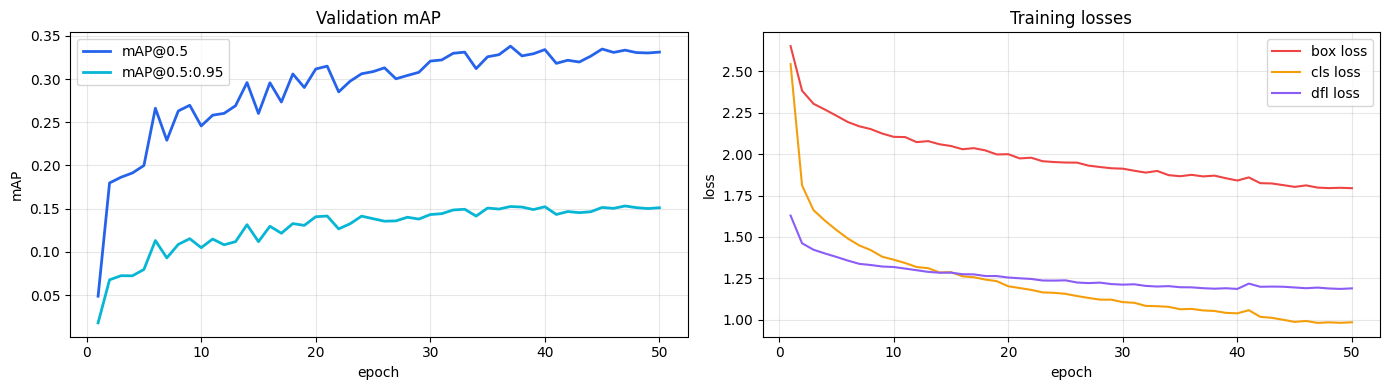

Best epoch: 37 -> mAP50=0.338, precision=0.473, recall=0.356


In [9]:
# 8. Plot the training curves so they're embedded in the notebook output.
import pandas as pd
import matplotlib.pyplot as plt

candidates = sorted(pathlib.Path('runs').glob('**/colab_loco_50ep'))
run_dir = next((p for p in candidates if (p / 'results.csv').is_file()), None)
if run_dir is None:
    run_dir = next((p for p in candidates if (p / 'weights' / 'best.pt').is_file()), None)
if run_dir is None:
    raise FileNotFoundError(
        'No run directory containing results.csv or weights/best.pt under runs/. '
        'Did cell 6 finish?  Candidates: ' + str(candidates)
    )
print('using run_dir =', run_dir)
df = pd.read_csv(run_dir / 'results.csv')
df.columns = [c.strip() for c in df.columns]

# Ultralytics has renamed results.csv columns across versions; resolve each
# metric by trying the known aliases so this cell survives version drift.
def col(*names):
    for n in names:
        if n in df.columns:
            return df[n]
    return None

ep      = col('epoch')
map50   = col('metrics/mAP50(B)', 'metrics/mAP_0.5', 'metrics/mAP50')
map5095 = col('metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95', 'metrics/mAP50-95')
prec    = col('metrics/precision(B)', 'metrics/precision')
rec     = col('metrics/recall(B)', 'metrics/recall')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if map50 is not None:   axes[0].plot(ep, map50,   label='mAP@0.5',     color='#2563EB', linewidth=2)
if map5095 is not None: axes[0].plot(ep, map5095, label='mAP@0.5:0.95', color='#06B6D4', linewidth=2)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('mAP'); axes[0].set_title('Validation mAP')
axes[0].grid(alpha=0.3); axes[0].legend()

for c, lab, color in [('train/box_loss', 'box loss', '#EF4444'),
                      ('train/cls_loss', 'cls loss', '#F59E0B'),
                      ('train/dfl_loss', 'dfl loss', '#8B5CF6')]:
    s = col(c)
    if s is not None:
        axes[1].plot(ep, s, label=lab, color=color)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss'); axes[1].set_title('Training losses')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

if map50 is not None:
    bi = map50.idxmax()
    p = f'{prec[bi]:.3f}' if prec is not None else 'n/a'
    r = f'{rec[bi]:.3f}' if rec is not None else 'n/a'
    print(f'Best epoch: {int(ep[bi])} -> mAP50={map50[bi]:.3f}, precision={p}, recall={r}')


In [10]:
# 9. Package best.pt + last.pt + results.csv + confusion matrix into a
#    single zip and trigger a Colab download to your machine.
import shutil
from datetime import datetime

candidates = sorted(pathlib.Path('runs').glob('**/colab_loco_50ep'))
run_dir = next((p for p in candidates if (p / 'results.csv').is_file()), None)
if run_dir is None:
    run_dir = next((p for p in candidates if (p / 'weights' / 'best.pt').is_file()), None)
if run_dir is None:
    raise FileNotFoundError(
        'No run directory containing results.csv or weights/best.pt under runs/. '
        'Did cell 6 finish?  Candidates: ' + str(candidates)
    )
print('using run_dir =', run_dir)
stamp = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
bundle = pathlib.Path(f'/content/logivision_colab_run_{stamp}')
bundle.mkdir(exist_ok=True)
for f in ('weights/best.pt', 'weights/last.pt', 'results.csv',
          'confusion_matrix.png', 'confusion_matrix_normalized.png',
          'args.yaml', 'labels.jpg'):
    src = run_dir / f
    if src.is_file():
        shutil.copy(src, bundle / pathlib.Path(f).name)
zip_path = shutil.make_archive(str(bundle), 'zip', bundle)
print(f'bundle: {zip_path} ({pathlib.Path(zip_path).stat().st_size/1e6:.1f} MB)')

# Trigger Colab download (or use right-click in the file panel if this fails)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)


using run_dir = runs/detect/runs/colab_loco_50ep


/tmp/ipykernel_1175/3517227595.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  stamp = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


bundle: /content/logivision_colab_run_20260617T220533Z.zip (11.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps on your laptop

After the download completes:

```bash
# 1. Unzip into the repo's ml/runs directory under a colab-named subdir.
RUN_NAME=$(basename ~/Downloads/logivision_colab_run_*.zip .zip)
mkdir -p ml/runs/$RUN_NAME/weights
unzip -o ~/Downloads/${RUN_NAME}.zip -d ml/runs/$RUN_NAME/
mv ml/runs/$RUN_NAME/best.pt ml/runs/$RUN_NAME/weights/best.pt
mv ml/runs/$RUN_NAME/last.pt ml/runs/$RUN_NAME/weights/last.pt

# 2. Register in your local MLflow + promote to Production.
make register-from-colab RUN=$RUN_NAME

# 3. Restart the inference worker so it picks up the new model.
make worker-restart
```

The dashboard's `System` tab will show the new model version + metrics on
next refresh. Detections start using the Colab-trained weights in ~10 s.

## Troubleshooting

| Symptom | Fix |
|---|---|
| LOCO download fails (cell 4) | Re-run the cell; the TUM link is occasionally slow. Check Colab has internet. |
| `CUDA out of memory` | Drop `batch=32` to `batch=16` in cell 6 |
| Training stalls at 0 mAP after 5+ epochs | Re-check `data.yaml` — classes/paths must match what cell 5 wrote |
| `files.download()` does nothing | Click the file panel on the left, right-click the zip, "Download" |
